# Import and reload everything

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
print("✅ Libraries loaded!")

✅ Libraries loaded!


# Reload and prepare news data

In [2]:
# Reload news
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
news_df = news_df.drop(columns=["Unnamed: 0"])

# Filter stocks
our_stocks = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA", "FB"]
filtered_news = news_df[news_df["stock"].isin(our_stocks)].copy()
filtered_news["stock"] = filtered_news["stock"].replace("FB", "META")

# Parse dates
filtered_news["date"] = pd.to_datetime(
    filtered_news["date"], format="mixed", utc=True
)
filtered_news["date_only"] = filtered_news["date"].dt.date

# Sentiment function
def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0.0

# Apply sentiment
print("🔄 Computing sentiment scores...")
filtered_news["polarity"] = filtered_news["headline"].apply(get_sentiment)
print(f"✅ Sentiment computed for {len(filtered_news):,} articles!")

🔄 Computing sentiment scores...
✅ Sentiment computed for 5,444 articles!


# Calculate daily average sentiment

In [3]:
# Calculate daily average sentiment per stock
daily_sentiment = filtered_news.groupby(
    ["stock", "date_only"]
).agg(
    avg_sentiment=("polarity", "mean"),
    article_count=("polarity", "count"),
    positive_count=("polarity", lambda x: (x > 0.1).sum()),
    negative_count=("polarity", lambda x: (x < -0.1).sum())
).reset_index()

daily_sentiment["date_only"] = pd.to_datetime(daily_sentiment["date_only"])

print("=== 📅 DAILY SENTIMENT SUMMARY ===")
print(f"Total trading days with news: {len(daily_sentiment):,}")
print(f"\nSample:")
print(daily_sentiment.head(10))

=== 📅 DAILY SENTIMENT SUMMARY ===
Total trading days with news: 1,774

Sample:
  stock  date_only  avg_sentiment  article_count  positive_count  \
0  AAPL 2020-03-09      -0.155556              3               0   
1  AAPL 2020-03-10       0.021708              8               2   
2  AAPL 2020-03-11       0.018624             14               2   
3  AAPL 2020-03-12      -0.083048              5               2   
4  AAPL 2020-03-13       0.069215             11               3   
5  AAPL 2020-03-14       0.250000              2               1   
6  AAPL 2020-03-15       0.196429              4               2   
7  AAPL 2020-03-16       0.011136             11               2   
8  AAPL 2020-03-17       0.034673             12               3   
9  AAPL 2020-03-18       0.104091              4               2   

   negative_count  
0               1  
1               1  
2               1  
3               1  
4               0  
5               0  
6               0  
7           

# Calculate daily stock returns

In [4]:
# Load and calculate daily returns for all stocks
stocks = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA"]
all_returns = []

for stock in stocks:
    df = pd.read_csv(f"../data/{stock}.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # Calculate daily return
    df["Daily_Return"] = df["Close"].pct_change() * 100
    df["stock"] = stock

    all_returns.append(df[["Date", "Close", "Daily_Return", "stock"]])

# Combine all stocks
returns_df = pd.concat(all_returns, ignore_index=True)
returns_df = returns_df.dropna()

print("=== 📈 DAILY RETURNS SUMMARY ===")
print(f"Total records: {len(returns_df):,}")
print(f"\nAverage daily returns:")
print(returns_df.groupby("stock")["Daily_Return"].mean().round(3))

=== 📈 DAILY RETURNS SUMMARY ===
Total records: 21,787

Average daily returns:
stock
AAPL    0.129
AMZN    0.130
GOOG    0.091
META    0.108
MSFT    0.100
NVDA    0.188
Name: Daily_Return, dtype: float64


# Merge sentiment with stock returns

In [5]:
# Merge sentiment with returns
merged_df = pd.merge(
    daily_sentiment,
    returns_df,
    left_on=["stock", "date_only"],
    right_on=["stock", "Date"],
    how="inner"
)

print("=== 🔗 MERGED DATASET ===")
print(f"Total matched records: {len(merged_df):,}")
print(f"\nRecords per stock:")
print(merged_df["stock"].value_counts())
print(f"\nSample:")
print(merged_df[["stock", "date_only", "avg_sentiment",
                  "Daily_Return", "article_count"]].head(10))

=== 🔗 MERGED DATASET ===
Total matched records: 1,640

Records per stock:
stock
NVDA    1125
GOOG     352
META      74
AAPL      61
AMZN      28
Name: count, dtype: int64

Sample:
  stock  date_only  avg_sentiment  Daily_Return  article_count
0  AAPL 2020-03-09      -0.155556     -7.909217              3
1  AAPL 2020-03-10       0.021708      7.202157              8
2  AAPL 2020-03-11       0.018624     -3.473025             14
3  AAPL 2020-03-12      -0.083048     -9.875496              5
4  AAPL 2020-03-13       0.069215     11.980808             11
5  AAPL 2020-03-16       0.011136    -12.864700             11
6  AAPL 2020-03-17       0.034673      4.397034             12
7  AAPL 2020-03-18       0.104091     -2.448005              4
8  AAPL 2020-03-19       0.000000     -0.766205              2
9  AAPL 2020-03-20       0.085417     -6.348547              2


# Correlation Analysis!!

In [6]:
print("=== 🎯 CORRELATION ANALYSIS ===\n")
print(f"{'Stock':<8} {'Correlation':>12} {'P-Value':>12} {'Significance':>15} {'Samples':>10}")
print("-" * 65)

correlation_results = {}

for stock in stocks:
    stock_df = merged_df[merged_df["stock"] == stock].copy()

    if len(stock_df) < 10:
        print(f"{stock:<8} {'Not enough data':>40}")
        continue

    # Pearson correlation
    corr, pvalue = stats.pearsonr(
        stock_df["avg_sentiment"],
        stock_df["Daily_Return"]
    )

    # Significance
    if pvalue < 0.01:
        sig = "*** Very Strong"
    elif pvalue < 0.05:
        sig = "** Strong"
    elif pvalue < 0.1:
        sig = "* Moderate"
    else:
        sig = "Not significant"

    correlation_results[stock] = {
        "correlation": corr,
        "pvalue": pvalue,
        "significance": sig,
        "samples": len(stock_df)
    }

    print(f"{stock:<8} {corr:>12.4f} {pvalue:>12.4f} {sig:>15} {len(stock_df):>10}")

=== 🎯 CORRELATION ANALYSIS ===

Stock     Correlation      P-Value    Significance    Samples
-----------------------------------------------------------------
AAPL           0.1581       0.2235 Not significant         61
AMZN          -0.0297       0.8805 Not significant         28
GOOG           0.0568       0.2877 Not significant        352
META           0.2951       0.0107       ** Strong         74
MSFT                              Not enough data
NVDA           0.1035       0.0005 *** Very Strong       1125


# Visualize correlations

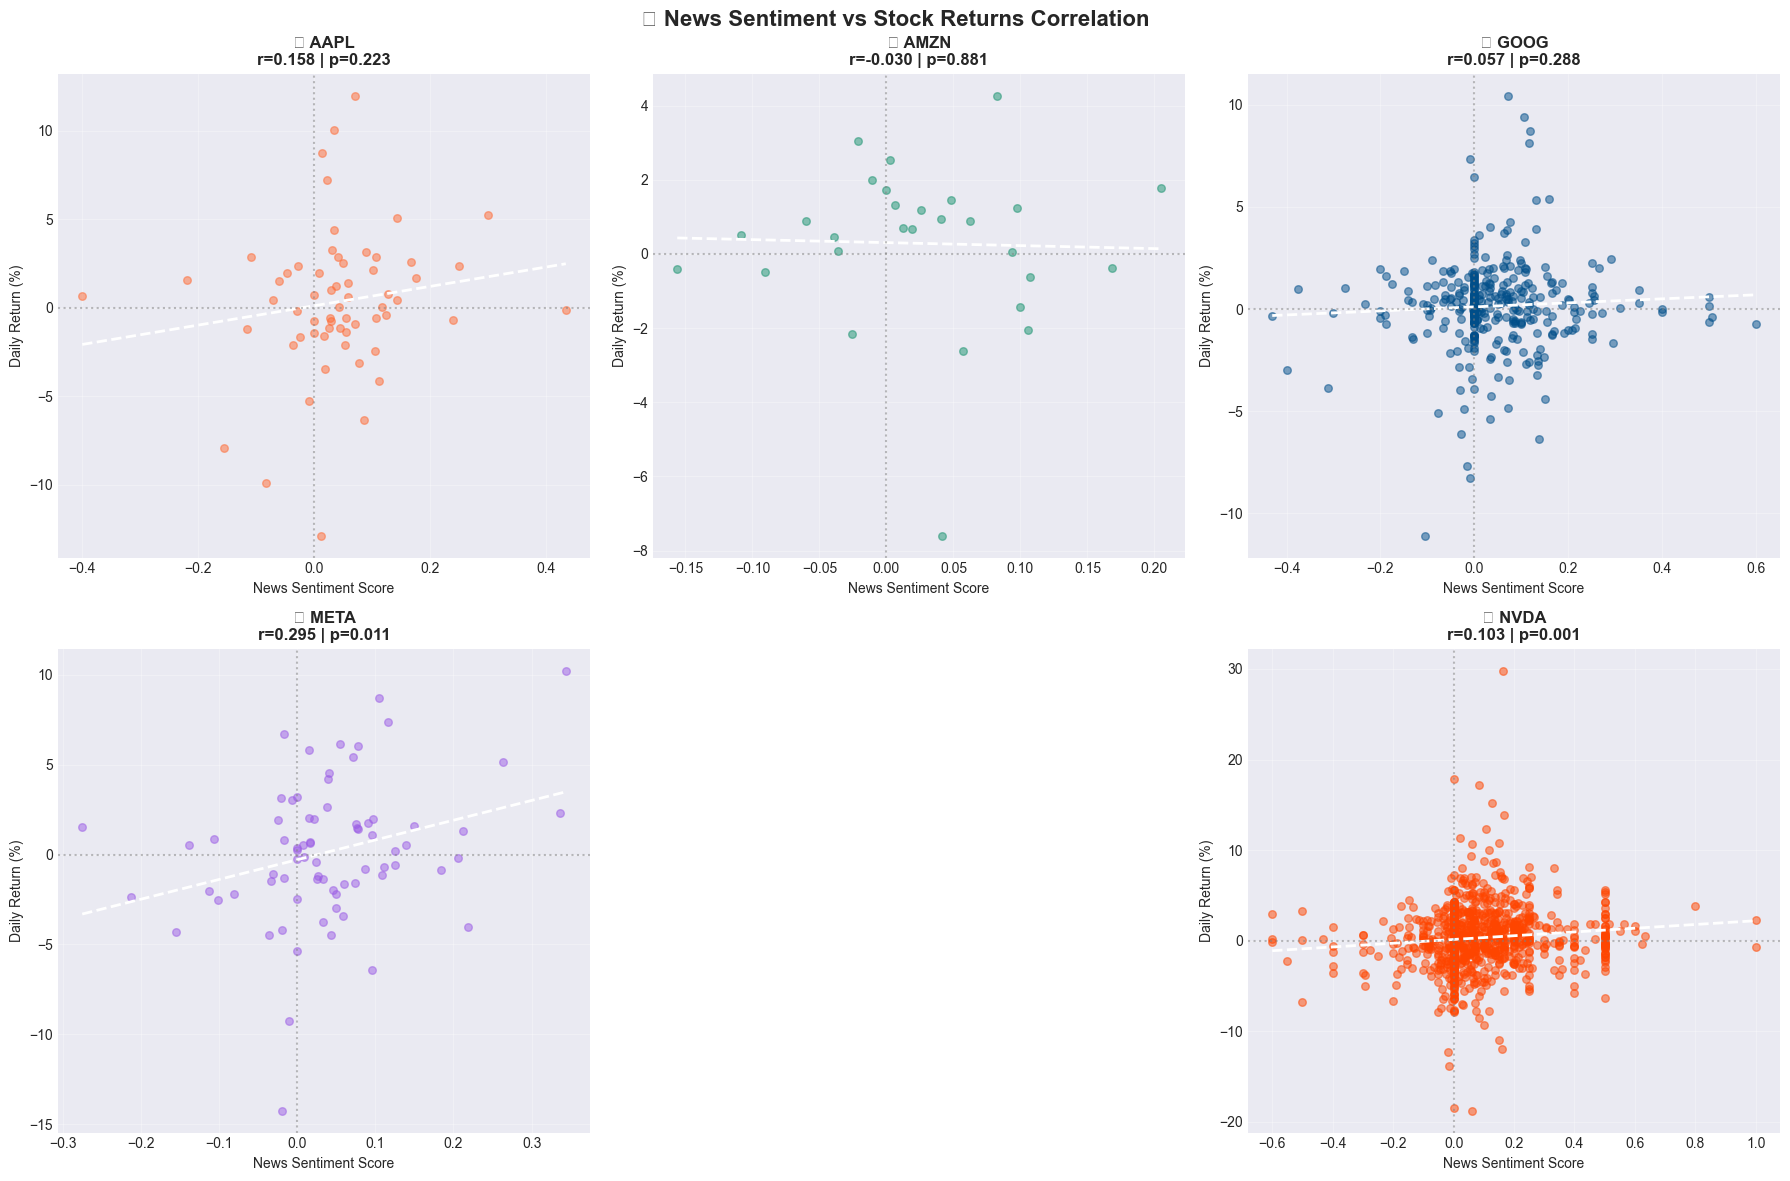

✅ Correlation chart saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("📈 News Sentiment vs Stock Returns Correlation",
             fontsize=16, fontweight="bold")

colors = ["#FF6B35", "#1A936F", "#004E89", "#9B5DE5", "#F7C59F", "#FF4500"]

for idx, stock in enumerate(stocks):
    ax = axes[idx // 3][idx % 3]
    stock_df = merged_df[merged_df["stock"] == stock].copy()

    if len(stock_df) < 5:
        ax.set_visible(False)
        continue

    corr = correlation_results.get(stock, {}).get("correlation", 0)
    pval = correlation_results.get(stock, {}).get("pvalue", 1)

    # Scatter plot
    ax.scatter(stock_df["avg_sentiment"],
               stock_df["Daily_Return"],
               alpha=0.5, color=colors[idx], s=30)

    # Trend line
    z = np.polyfit(stock_df["avg_sentiment"],
                   stock_df["Daily_Return"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(stock_df["avg_sentiment"].min(),
                         stock_df["avg_sentiment"].max(), 100)
    ax.plot(x_line, p(x_line), color="white",
            linewidth=2, linestyle="--")

    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5)
    ax.axvline(x=0, color="gray", linestyle=":", alpha=0.5)

    ax.set_title(f"📊 {stock}\nr={corr:.3f} | p={pval:.3f}",
                 fontweight="bold")
    ax.set_xlabel("News Sentiment Score")
    ax.set_ylabel("Daily Return (%)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/sentiment_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Correlation chart saved!")

# Investment Strategy Recommendations

In [8]:
print("=" * 60)
print("💰 INVESTMENT STRATEGY RECOMMENDATIONS")
print("=" * 60)

for stock, results in correlation_results.items():
    corr = results["correlation"]
    sig  = results["significance"]

    print(f"\n📊 {stock}")
    print(f"   Correlation: {corr:+.4f}")
    print(f"   Significance: {sig}")

    if corr > 0.2 and "Strong" in sig:
        print(f"   💡 Strategy: STRONG SIGNAL!")
        print(f"      → Buy when daily sentiment > +0.1")
        print(f"      → Sell when daily sentiment < -0.1")
    elif corr > 0.1:
        print(f"   💡 Strategy: WEAK SIGNAL")
        print(f"      → Use sentiment as ONE of many indicators")
        print(f"      → Combine with RSI and MACD for better accuracy")
    else:
        print(f"   💡 Strategy: NO CLEAR SIGNAL")
        print(f"      → News sentiment alone cannot predict {stock}")
        print(f"      → Focus on technical indicators instead")

print("\n" + "=" * 60)
print("📌 OVERALL FINDING:")
avg_corr = np.mean([r["correlation"] for r in correlation_results.values()])
print(f"   Average correlation across all stocks: {avg_corr:+.4f}")
if abs(avg_corr) > 0.2:
    print("   ✅ News sentiment IS a useful predictor!")
elif abs(avg_corr) > 0.1:
    print("   ⚠️ News sentiment has WEAK predictive power!")
else:
    print("   ❌ News sentiment alone is NOT sufficient!")
print("   💡 Best strategy: Combine sentiment + technical indicators!")
print("=" * 60)

💰 INVESTMENT STRATEGY RECOMMENDATIONS

📊 AAPL
   Correlation: +0.1581
   Significance: Not significant
   💡 Strategy: WEAK SIGNAL
      → Use sentiment as ONE of many indicators
      → Combine with RSI and MACD for better accuracy

📊 AMZN
   Correlation: -0.0297
   Significance: Not significant
   💡 Strategy: NO CLEAR SIGNAL
      → News sentiment alone cannot predict AMZN
      → Focus on technical indicators instead

📊 GOOG
   Correlation: +0.0568
   Significance: Not significant
   💡 Strategy: NO CLEAR SIGNAL
      → News sentiment alone cannot predict GOOG
      → Focus on technical indicators instead

📊 META
   Correlation: +0.2951
   Significance: ** Strong
   💡 Strategy: STRONG SIGNAL!
      → Buy when daily sentiment > +0.1
      → Sell when daily sentiment < -0.1

📊 NVDA
   Correlation: +0.1035
   Significance: *** Very Strong
   💡 Strategy: WEAK SIGNAL
      → Use sentiment as ONE of many indicators
      → Combine with RSI and MACD for better accuracy

📌 OVERALL FINDING:
  